In [2]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)


Filter for Vietnam Data Analyst roles


In [4]:
df_DA_VN = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Vietnam')].copy()

Text(0, 0.5, '')

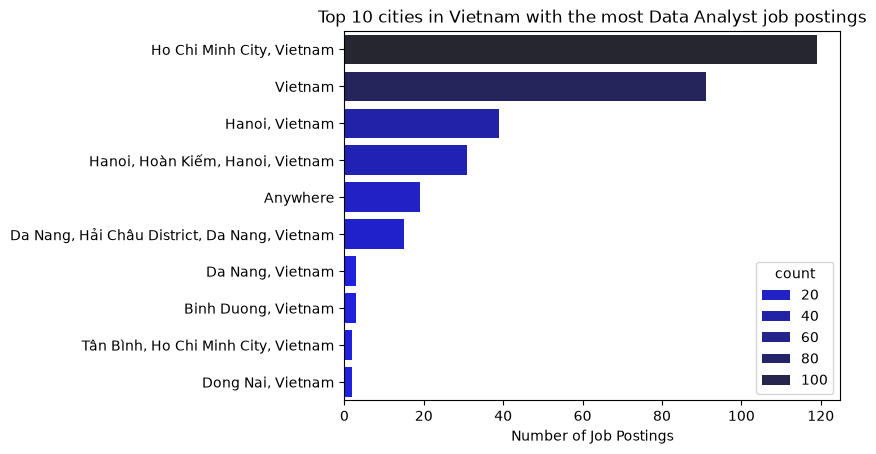

In [18]:
df_plot = df_DA_VN['job_location'].value_counts().head(10).to_frame()
sns.barplot(data=df_plot,x ='count', y= 'job_location',hue='count',palette = 'dark:b_r' )
plt.title('Top 10 cities in Vietnam with the most Data Analyst job postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('')

In [27]:
df_DA_VN[['job_work_from_home','job_no_degree_mention','job_health_insurance']]


,job_work_from_home,job_no_degree_mention,job_health_insurance
3056,False,True,False
10122,False,False,False
13878,False,False,False
26187,True,True,False
31673,False,True,False
...,...,...,...
782471,False,False,False
783227,False,False,False
783405,False,False,False
783486,False,True,False


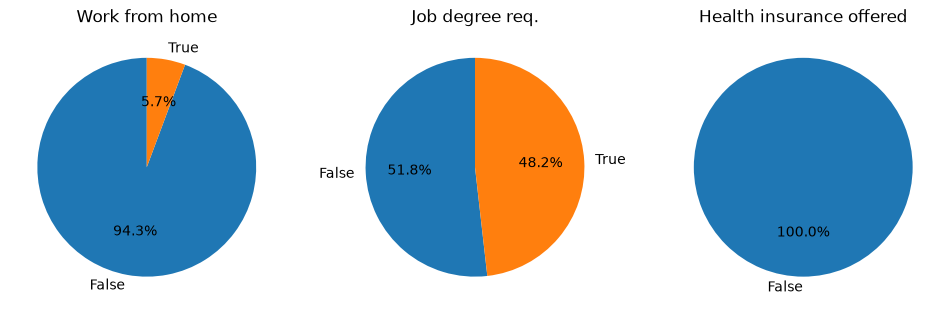

In [31]:


dict_column = {
    'job_work_from_home':'Work from home',
    'job_no_degree_mention': 'Job degree req.',
    'job_health_insurance':'Health insurance offered'
}

fig,ax = plt.subplots(1,3)
fig.set_size_inches(12,5)

for i, (column,title) in enumerate(dict_column.items()):
    counts = df_DA_VN[column].value_counts()
    ax[i].pie(df_DA_VN[column].value_counts(),   labels=counts.index ,startangle= 90, autopct ='%1.1f%%')
    ax[i].set_title(title)
plt.show()


Text(0, 0.5, '')

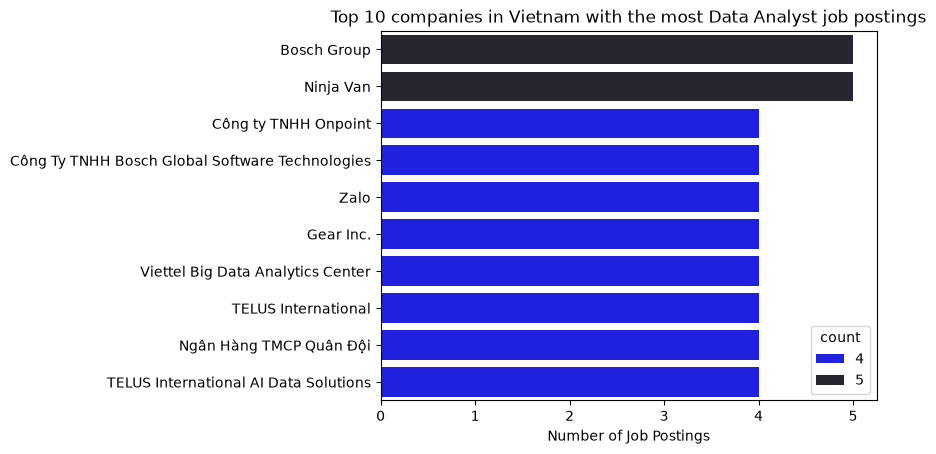

In [32]:
df_plot = df_DA_VN['company_name'].value_counts().head(10).to_frame()
sns.barplot(data=df_plot,x ='count', y= 'company_name',hue='count',palette = 'dark:b_r' )
plt.title('Top 10 companies in Vietnam with the most Data Analyst job postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('')